
# Pengembangan Model KNN Computational Thinking — 64 Data Empiris

Notebook ini dibuat mengikuti alur notebook lama, tetapi menggunakan metodologi yang disesuaikan dengan kondisi dataset terbaru.

## Sumber data

- Dataset model hanya berasal dari **XI RPL 2 dan XI RPL 3**.
- **XI RPL 1 tidak digunakan** dalam pelatihan, resampling, pemilihan parameter, cross-validation, maupun evaluasi model.
- Jumlah data empiris: **64 siswa**.
- Fitur: skor `D`, `P`, `A`, dan `Alg`.
- Label: `rendah`, `sedang`, dan `tinggi`.

## Tujuan notebook

1. Memvalidasi dataset.
2. Menyiapkan fitur dan label.
3. Membandingkan tiga strategi:
   - KNN tanpa resampling;
   - RandomOverSampler + KNN;
   - SMOTE + KNN.
4. Menggunakan nested group-aware cross-validation.
5. Memilih satu pipeline terbaik berdasarkan macro F1-score.
6. Melatih model final dengan seluruh 64 data.
7. Mengekspor model final menjadi file `.pkl`.


## Setup Library

In [10]:

import sys
import subprocess
import importlib.util
from pathlib import Path
import json
import re
import warnings

# Instal imbalanced-learn otomatis jika belum tersedia.
if importlib.util.find_spec("imblearn") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "imbalanced-learn"
    ])

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedGroupKFold,
    GridSearchCV
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Library berhasil dimuat.")


Library berhasil dimuat.


## Tahap 1 — Pengumpulan dan Pelabelan Data

### Load Data

In [11]:

DATA_FILE = "labeled_empirical_64_validated.csv"

BASE_DIR = Path.cwd()
if not (BASE_DIR / DATA_FILE).exists():
    BASE_DIR = Path("/mnt/data")

DATA_PATH = BASE_DIR / DATA_FILE

df = pd.read_csv(DATA_PATH)

print("Lokasi data:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())


Lokasi data: d:\Skripsi\mlKNN\labeled_empirical_64_validated.csv
Shape: (64, 9)


,nis,nama,kelas_mapped,A,Alg,D,P,total_score,label_ct
0,2425120636,ALFINUS PRASETYA,XI RPL 2,12,8,14,12,46,tinggi
1,2425120637,AMELIA CAHYA ANGGRAENI,XI RPL 2,14,8,12,12,46,tinggi
2,2425120638,ANDIKA,XI RPL 2,12,8,10,10,40,tinggi
3,2425120639,ASEP SULAEMAN,XI RPL 2,14,11,14,11,50,tinggi
4,2425120640,AZRIL HADHI ALFIANSYAH,XI RPL 2,14,14,14,14,56,tinggi



### Cek Struktur Kolom, Kelas Sumber, dan Missing Value

Dataset hanya boleh berisi siswa XI RPL 2 dan XI RPL 3. XI RPL 1 harus bernilai nol.


In [12]:

required_columns = [
    "nis",
    "nama",
    "kelas_mapped",
    "D",
    "P",
    "A",
    "Alg",
    "total_score",
    "label_ct"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Kolom wajib tidak ditemukan: {missing_columns}"
    )

df["nis"] = df["nis"].astype(str).str.strip()
df["nama"] = df["nama"].astype(str).str.strip()
df["kelas_mapped"] = (
    df["kelas_mapped"]
    .astype(str)
    .str.strip()
    .str.upper()
)
df["label_ct"] = (
    df["label_ct"]
    .astype(str)
    .str.strip()
    .str.lower()
)

for col in ["D", "P", "A", "Alg", "total_score"]:
    df[col] = pd.to_numeric(
        df[col],
        errors="raise"
    ).astype(int)

print("Daftar kolom:")
print(df.columns.tolist())

print("\nMissing value per kolom:")
print(df[required_columns].isna().sum())

print("\nDistribusi kelas sumber:")
print(df["kelas_mapped"].value_counts())

jumlah_rpl1 = int(
    df["kelas_mapped"]
    .str.contains(r"RPL\s*1", regex=True)
    .sum()
)

if jumlah_rpl1 > 0:
    raise ValueError(
        "Dataset masih mengandung XI RPL 1. "
        "Data tersebut tidak boleh digunakan."
    )

allowed_classes = {"XI RPL 2", "XI RPL 3"}
unexpected_classes = sorted(
    set(df["kelas_mapped"]) - allowed_classes
)

if unexpected_classes:
    raise ValueError(
        f"Ada kelas di luar XI RPL 2/3: {unexpected_classes}"
    )

print("\nValidasi sumber kelas berhasil.")
print("XI RPL 1:", jumlah_rpl1, "data")


Daftar kolom:
['nis', 'nama', 'kelas_mapped', 'A', 'Alg', 'D', 'P', 'total_score', 'label_ct']

Missing value per kolom:
nis             0
nama            0
kelas_mapped    0
D               0
P               0
A               0
Alg             0
total_score     0
label_ct        0
dtype: int64

Distribusi kelas sumber:
kelas_mapped
XI RPL 2    34
XI RPL 3    30
Name: count, dtype: int64

Validasi sumber kelas berhasil.
XI RPL 1: 0 data


### Validasi Jumlah Data dan Distribusi Label

In [13]:

if len(df) != 64:
    raise ValueError(
        f"Jumlah data harus 64, tetapi ditemukan {len(df)}."
    )

allowed_labels = {"rendah", "sedang", "tinggi"}
unexpected_labels = sorted(
    set(df["label_ct"]) - allowed_labels
)

if unexpected_labels:
    raise ValueError(
        f"Label tidak dikenal: {unexpected_labels}"
    )

label_distribution = (
    df["label_ct"]
    .value_counts()
    .reindex(
        ["rendah", "sedang", "tinggi"],
        fill_value=0
    )
)

print("Jumlah data:", len(df))
print("\nDistribusi label:")
print(label_distribution)


Jumlah data: 64

Distribusi label:
label_ct
rendah     7
sedang    13
tinggi    44
Name: count, dtype: int64


### Validasi Skor dan Aturan Label

In [14]:

FEATURES = ["D", "P", "A", "Alg"]

def expected_label(row):
    total = int(row["total_score"])
    minimum_indicator = int(row[FEATURES].min())

    if total >= 40:
        if minimum_indicator < 7:
            return "sedang"
        return "tinggi"

    if total >= 25:
        if minimum_indicator < 4:
            return "rendah"
        return "sedang"

    return "rendah"


# 1. Rentang skor setiap indikator.
range_violations = {}

for col in FEATURES:
    invalid_count = int(
        (~df[col].between(0, 14)).sum()
    )
    range_violations[col] = invalid_count

print("Data di luar rentang 0–14:")
print(range_violations)


# 2. Total skor harus sama dengan jumlah empat indikator.
df["total_recalculated"] = df[FEATURES].sum(axis=1)

total_mismatch = int(
    (
        df["total_score"]
        != df["total_recalculated"]
    ).sum()
)

print("\nKetidaksesuaian total skor:", total_mismatch)


# 3. Label harus sesuai rubrik pelabelan.
df["label_recalculated"] = df.apply(
    expected_label,
    axis=1
)

label_mismatch = int(
    (
        df["label_ct"]
        != df["label_recalculated"]
    ).sum()
)

print("Ketidaksesuaian label:", label_mismatch)


if (
    sum(range_violations.values()) > 0
    or total_mismatch > 0
    or label_mismatch > 0
):
    problem_rows = df[
        (
            df["total_score"]
            != df["total_recalculated"]
        )
        |
        (
            df["label_ct"]
            != df["label_recalculated"]
        )
    ]

    display(problem_rows)

    raise ValueError(
        "Validasi skor atau label gagal."
    )

print("\nSemua skor dan label valid.")


Data di luar rentang 0–14:
{'D': 0, 'P': 0, 'A': 0, 'Alg': 0}

Ketidaksesuaian total skor: 0
Ketidaksesuaian label: 0

Semua skor dan label valid.


## Tahap 2 — Pra-pemrosesan Data

### Cek Duplikasi

In [15]:

duplicate_nis = int(
    df["nis"].duplicated().sum()
)

duplicate_full_rows = int(
    df[required_columns].duplicated().sum()
)

duplicate_profiles = int(
    df.duplicated(
        subset=FEATURES,
        keep=False
    ).sum()
)

print("NIS duplikat:", duplicate_nis)
print("Baris identik penuh:", duplicate_full_rows)
print(
    "Baris yang berbagi profil skor:",
    duplicate_profiles
)

if duplicate_nis > 0:
    raise ValueError(
        "Terdapat NIS ganda pada dataset."
    )


NIS duplikat: 0
Baris identik penuh: 0
Baris yang berbagi profil skor: 21



### Tentukan Fitur dan Label

Urutan fitur wajib:

```python
[D, P, A, Alg]
```

Urutan tersebut sama dengan fungsi prediksi pada `utils.py`.

Identitas siswa tidak digunakan sebagai fitur model.


In [16]:

LABEL_TO_INT = {
    "rendah": 0,
    "sedang": 1,
    "tinggi": 2
}

INT_TO_LABEL = {
    0: "rendah",
    1: "sedang",
    2: "tinggi"
}

X = df[FEATURES].to_numpy(dtype=float)

y = (
    df["label_ct"]
    .map(LABEL_TO_INT)
    .to_numpy(dtype=int)
)

# Profil skor identik diperlakukan sebagai satu grup
# agar tidak tersebar ke train dan test.
profile_groups = (
    df[FEATURES]
    .astype(str)
    .agg("|".join, axis=1)
    .to_numpy()
)

print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)
print("Jumlah profil unik:", len(np.unique(profile_groups)))
print("Urutan fitur:", FEATURES)
print("Pemetaan label:", LABEL_TO_INT)


Bentuk X: (64, 4)
Bentuk y: (64,)
Jumlah profil unik: 50
Urutan fitur: ['D', 'P', 'A', 'Alg']
Pemetaan label: {'rendah': 0, 'sedang': 1, 'tinggi': 2}


### Visualisasi Distribusi Label

,label_ct,jumlah
0,rendah,7
1,sedang,13
2,tinggi,44


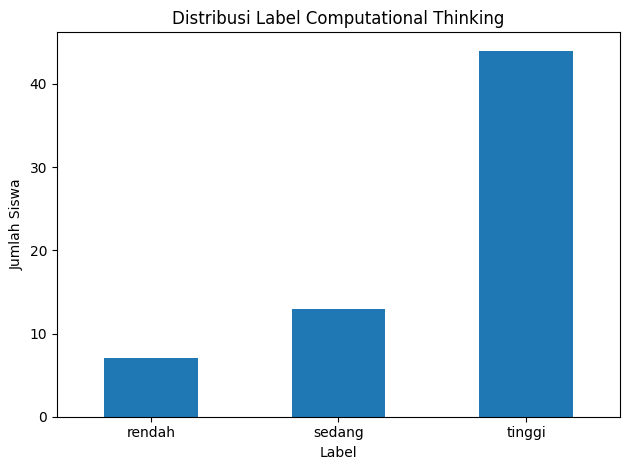

In [17]:

distribution_df = (
    label_distribution
    .rename_axis("label_ct")
    .reset_index(name="jumlah")
)

display(distribution_df)

ax = distribution_df.plot(
    x="label_ct",
    y="jumlah",
    kind="bar",
    legend=False,
    title="Distribusi Label Computational Thinking"
)

ax.set_xlabel("Label")
ax.set_ylabel("Jumlah Siswa")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Tahap 3 — Menentukan Strategi Pemodelan

Tiga kandidat dibandingkan dengan fold evaluasi yang sama:

1. **KNN tanpa resampling**
2. **RandomOverSampler + KNN**
3. **SMOTE + KNN**

Resampling hanya dilakukan pada data training di dalam pipeline. Data test pada setiap fold tetap berupa data empiris asli.

Karena kelas rendah hanya memiliki tujuh data, SMOTE menggunakan `k_neighbors=1` agar dapat dijalankan secara aman pada training fold kecil.


In [18]:

K_CANDIDATES = [3, 5, 7, 9, 11]
WEIGHT_CANDIDATES = [
    "uniform",
    "distance"
]

candidate_pipelines = {
    "KNN": Pipeline([
        (
            "knn",
            KNeighborsClassifier(
                metric="euclidean"
            )
        )
    ]),

    "RandomOverSampler + KNN": Pipeline([
        (
            "sampler",
            RandomOverSampler(
                random_state=RANDOM_STATE
            )
        ),
        (
            "knn",
            KNeighborsClassifier(
                metric="euclidean"
            )
        )
    ]),

    "SMOTE + KNN": Pipeline([
        (
            "sampler",
            SMOTE(
                random_state=RANDOM_STATE,
                k_neighbors=1
            )
        ),
        (
            "knn",
            KNeighborsClassifier(
                metric="euclidean"
            )
        )
    ])
}

parameter_grid = {
    "knn__n_neighbors": K_CANDIDATES,
    "knn__weights": WEIGHT_CANDIDATES
}

print("Kandidat pipeline:")
for name in candidate_pipelines:
    print("-", name)

print("\nK kandidat:", K_CANDIDATES)
print("Bobot tetangga:", WEIGHT_CANDIDATES)


Kandidat pipeline:
- KNN
- RandomOverSampler + KNN
- SMOTE + KNN

K kandidat: [3, 5, 7, 9, 11]
Bobot tetangga: ['uniform', 'distance']



## Tahap 4 — Nested Group-Aware Cross-Validation

- **Outer 5-fold:** mengukur performa model.
- **Inner 3-fold:** memilih nilai `k` dan jenis bobot KNN.
- **Stratified:** mempertahankan distribusi kelas sebisa mungkin.
- **Grouped:** profil skor identik tidak masuk ke train dan test secara bersamaan.
- **Metrik pemilihan:** macro F1-score.


In [19]:

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Dibuat sekali agar semua kandidat
# menggunakan pembagian outer fold yang sama.
outer_splits = list(
    outer_cv.split(
        X,
        y,
        groups=profile_groups
    )
)

fold_records = []
candidate_predictions = {}

for candidate_name, pipeline in candidate_pipelines.items():

    all_true = []
    all_pred = []
    all_test_indices = []

    for fold_number, (train_idx, test_idx) in enumerate(
        outer_splits,
        start=1
    ):

        inner_cv = StratifiedGroupKFold(
            n_splits=3,
            shuffle=True,
            random_state=RANDOM_STATE + fold_number
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=parameter_grid,
            scoring="f1_macro",
            cv=inner_cv,
            refit=True,
            n_jobs=1,
            error_score="raise"
        )

        search.fit(
            X[train_idx],
            y[train_idx],
            groups=profile_groups[train_idx]
        )

        fold_prediction = search.predict(
            X[test_idx]
        )

        macro_precision, macro_recall, macro_f1, _ = (
            precision_recall_fscore_support(
                y[test_idx],
                fold_prediction,
                average="macro",
                zero_division=0
            )
        )

        class_recalls = (
            precision_recall_fscore_support(
                y[test_idx],
                fold_prediction,
                labels=[0, 1, 2],
                zero_division=0
            )[1]
        )

        fold_records.append({
            "candidate": candidate_name,
            "fold": fold_number,
            "train_size": len(train_idx),
            "test_size": len(test_idx),
            "best_k": int(
                search.best_params_[
                    "knn__n_neighbors"
                ]
            ),
            "best_weights": search.best_params_[
                "knn__weights"
            ],
            "accuracy": accuracy_score(
                y[test_idx],
                fold_prediction
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y[test_idx],
                fold_prediction
            ),
            "macro_precision": macro_precision,
            "macro_recall": macro_recall,
            "macro_f1": macro_f1,
            "recall_rendah": class_recalls[0],
            "recall_sedang": class_recalls[1],
            "recall_tinggi": class_recalls[2]
        })

        all_true.extend(
            y[test_idx].tolist()
        )

        all_pred.extend(
            fold_prediction.tolist()
        )

        all_test_indices.extend(
            test_idx.tolist()
        )

    candidate_predictions[candidate_name] = {
        "y_true": np.asarray(
            all_true,
            dtype=int
        ),
        "y_pred": np.asarray(
            all_pred,
            dtype=int
        ),
        "test_indices": np.asarray(
            all_test_indices,
            dtype=int
        )
    }

fold_results_df = pd.DataFrame(
    fold_records
)

display(fold_results_df)


,candidate,fold,train_size,test_size,best_k,best_weights,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,recall_rendah,recall_sedang,recall_tinggi
0,KNN,1,56,8,3,uniform,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
1,KNN,2,53,11,7,distance,0.727273,0.666667,0.875000,0.666667,0.700855,0.5,0.500000,1.000000
2,KNN,3,50,14,3,uniform,0.857143,0.666667,0.500000,0.666667,0.555556,0.0,1.000000,1.000000
3,KNN,4,44,20,3,uniform,0.900000,0.555556,0.535948,0.555556,0.545455,0.0,0.666667,1.000000
4,KNN,5,53,11,3,distance,0.818182,0.777778,0.925926,0.777778,0.791667,1.0,0.333333,1.000000
5,RandomOverSampler + KNN,1,56,8,11,uniform,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
6,RandomOverSampler + KNN,2,53,11,5,uniform,0.727273,0.683333,0.800000,0.683333,0.711111,0.5,0.750000,0.800000
7,RandomOverSampler + KNN,3,50,14,11,distance,0.857143,0.933333,0.833333,0.933333,0.851852,1.0,1.000000,0.800000
8,RandomOverSampler + KNN,4,44,20,3,uniform,0.950000,0.979167,0.916667,0.979167,0.941628,1.0,1.000000,0.937500
9,RandomOverSampler + KNN,5,53,11,5,uniform,0.909091,0.952381,0.916667,0.952381,0.926740,1.0,1.000000,0.857143


## Tahap 5 — Evaluasi dan Perbandingan Model

In [22]:

comparison_rows = []

for candidate_name, prediction_data in (
    candidate_predictions.items()
):
    y_true_candidate = prediction_data["y_true"]
    y_pred_candidate = prediction_data["y_pred"]

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true_candidate,
            y_pred_candidate,
            average="macro",
            zero_division=0
        )
    )

    class_recalls = (
        precision_recall_fscore_support(
            y_true_candidate,
            y_pred_candidate,
            labels=[0, 1, 2],
            zero_division=0
        )[1]
    )

    candidate_fold_rows = fold_results_df[
        fold_results_df["candidate"]
        == candidate_name
    ]

    comparison_rows.append({
        "candidate": candidate_name,
        "accuracy": accuracy_score(
            y_true_candidate,
            y_pred_candidate
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true_candidate,
            y_pred_candidate
        ),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "macro_f1_fold_std": (
            candidate_fold_rows[
                "macro_f1"
            ].std()
        ),
        "recall_rendah": class_recalls[0],
        "recall_sedang": class_recalls[1],
        "recall_tinggi": class_recalls[2]
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        by=[
            "macro_f1",
            "balanced_accuracy",
            "recall_rendah",
            "macro_f1_fold_std"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(comparison_df)


,candidate,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,macro_f1_fold_std,recall_rendah,recall_sedang,recall_tinggi
0,SMOTE + KNN,0.921875,0.885947,0.913420,0.885947,0.897479,0.130938,0.857143,0.846154,0.954545
1,RandomOverSampler + KNN,0.890625,0.888861,0.880556,0.888861,0.875281,0.111245,0.857143,0.923077,0.886364
2,KNN,0.859375,0.681319,0.869091,0.681319,0.734279,0.188018,0.428571,0.615385,1.000000


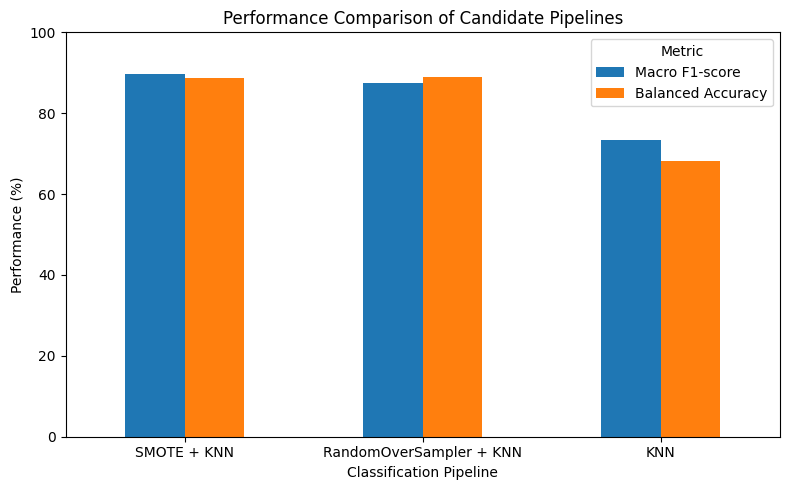

In [23]:
# Menyiapkan data grafik dalam bentuk persen
comparison_plot = (
    comparison_df[
        ["candidate", "macro_f1", "balanced_accuracy"]
    ]
    .set_index("candidate")
    .rename(columns={
        "macro_f1": "Macro F1-score",
        "balanced_accuracy": "Balanced Accuracy"
    })
    * 100
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Performance Comparison of Candidate Pipelines")
ax.set_xlabel("Classification Pipeline")
ax.set_ylabel("Performance (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "fig3a_pipeline_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Pilih Pipeline Terbaik

Urutan keputusan:

1. Macro F1-score tertinggi.
2. Balanced accuracy tertinggi.
3. Recall kelas rendah tertinggi.
4. Standar deviasi macro F1 antar-fold terendah.

Hanya pipeline terbaik yang akan digunakan pada aplikasi.


Pipeline terbaik: SMOTE + KNN

Classification Report:
              precision    recall  f1-score   support

      rendah     1.0000    0.8571    0.9231         7
      sedang     0.7857    0.8462    0.8148        13
      tinggi     0.9545    0.9545    0.9545        44

    accuracy                         0.9219        64
   macro avg     0.9134    0.8859    0.8975        64
weighted avg     0.9252    0.9219    0.9227        64



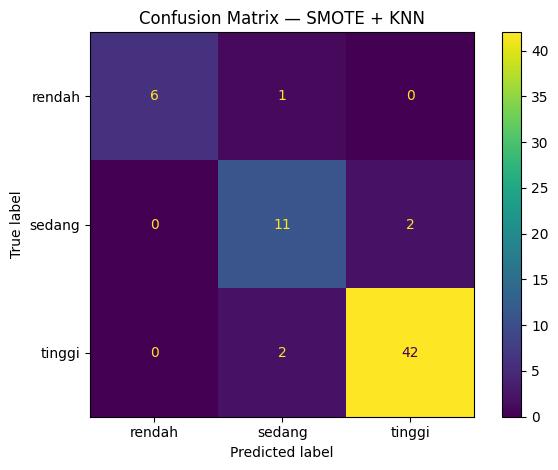

In [24]:

best_candidate_name = str(
    comparison_df.iloc[0]["candidate"]
)

print(
    "Pipeline terbaik:",
    best_candidate_name
)

best_prediction_data = candidate_predictions[
    best_candidate_name
]

best_y_true = best_prediction_data["y_true"]
best_y_pred = best_prediction_data["y_pred"]

print("\nClassification Report:")
print(
    classification_report(
        best_y_true,
        best_y_pred,
        target_names=[
            "rendah",
            "sedang",
            "tinggi"
        ],
        digits=4,
        zero_division=0
    )
)

best_confusion_matrix = confusion_matrix(
    best_y_true,
    best_y_pred,
    labels=[0, 1, 2]
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=best_confusion_matrix,
    display_labels=[
        "rendah",
        "sedang",
        "tinggi"
    ]
)

display_cm.plot(values_format="d")
plt.title(
    f"Confusion Matrix — {best_candidate_name}"
)
plt.tight_layout()
plt.show()



## Tahap 6 — Menentukan Hyperparameter Final

Setelah pipeline terbaik dipilih, nilai `k` dan `weights` ditentukan kembali menggunakan seluruh 64 data melalui group-aware 5-fold cross-validation.


In [13]:

final_selection_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

selected_pipeline = candidate_pipelines[
    best_candidate_name
]

final_search = GridSearchCV(
    estimator=selected_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=final_selection_cv,
    refit=True,
    n_jobs=1,
    error_score="raise",
    return_train_score=True
)

final_search.fit(
    X,
    y,
    groups=profile_groups
)

best_k = int(
    final_search.best_params_[
        "knn__n_neighbors"
    ]
)

best_weights = str(
    final_search.best_params_[
        "knn__weights"
    ]
)

grid_results_df = (
    pd.DataFrame(
        final_search.cv_results_
    )[
        [
            "param_knn__n_neighbors",
            "param_knn__weights",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values(
        by=[
            "rank_test_score",
            "param_knn__n_neighbors"
        ]
    )
    .reset_index(drop=True)
)

display(grid_results_df)

print("Pipeline final:", best_candidate_name)
print("Best K:", best_k)
print("Best weights:", best_weights)
print(
    "Mean CV macro F1:",
    final_search.best_score_
)


,param_knn__n_neighbors,param_knn__weights,mean_test_score,std_test_score,rank_test_score
0,9,distance,0.927570,0.111887,1
1,11,distance,0.927570,0.111887,1
2,7,distance,0.838681,0.176769,3
3,5,distance,0.821587,0.171480,4
4,9,uniform,0.815824,0.138528,5
5,11,uniform,0.815824,0.138528,5
6,3,distance,0.789392,0.139562,7
7,7,uniform,0.762491,0.172874,8
8,5,uniform,0.745397,0.159495,9
9,3,uniform,0.743271,0.127777,10


Pipeline final: SMOTE + KNN
Best K: 9
Best weights: distance
Mean CV macro F1: 0.9275702075702077



## Tahap 7 — Melatih Model Final dengan Seluruh Data

Model deployment dilatih menggunakan seluruh 64 data empiris setelah strategi dan parameter dipilih.


In [14]:

final_pipeline = final_search.best_estimator_

# GridSearchCV dengan refit=True sudah melatih
# estimator terbaik pada seluruh dataset.
print(final_pipeline)


Pipeline(steps=[('sampler', SMOTE(k_neighbors=1, random_state=42)),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=9,
                                      weights='distance'))])


## Tahap 8 — Simpan Model ke File `.pkl`

In [15]:

def slugify_model_name(name):
    return (
        name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
    )

model_slug = slugify_model_name(
    best_candidate_name
)

MODEL_FILENAME = (
    f"knn_ct_final_{model_slug}_k{best_k}.pkl"
)

MODEL_PATH = BASE_DIR / MODEL_FILENAME

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

comparison_path = (
    BASE_DIR
    / "knn_ct_model_comparison.csv"
)

fold_results_path = (
    BASE_DIR
    / "knn_ct_fold_results.csv"
)

grid_results_path = (
    BASE_DIR
    / "knn_ct_final_grid_results.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

fold_results_df.to_csv(
    fold_results_path,
    index=False
)

grid_results_df.to_csv(
    grid_results_path,
    index=False
)

best_comparison_row = (
    comparison_df.iloc[0].to_dict()
)

metadata = {
    "dataset": DATA_FILE,
    "dataset_type": "empirical",
    "source_classes": [
        "XI RPL 2",
        "XI RPL 3"
    ],
    "excluded_class": "XI RPL 1",
    "n_records": int(len(df)),
    "class_distribution": {
        label: int(count)
        for label, count
        in label_distribution.items()
    },
    "features": FEATURES,
    "feature_range": "0-14",
    "label_to_int": LABEL_TO_INT,
    "int_to_label": {
        str(key): value
        for key, value
        in INT_TO_LABEL.items()
    },
    "selected_pipeline": best_candidate_name,
    "distance_metric": "euclidean",
    "best_k": best_k,
    "best_weights": best_weights,
    "selection_metric": "macro_f1",
    "nested_cv_evaluation": {
        key: (
            float(value)
            if isinstance(
                value,
                (int, float, np.integer, np.floating)
            )
            else value
        )
        for key, value
        in best_comparison_row.items()
    },
    "confusion_matrix": (
        best_confusion_matrix.tolist()
    ),
    "notes": [
        (
            "XI RPL 1 was completely excluded "
            "from model development and evaluation."
        ),
        (
            "Resampling, when selected, was "
            "performed only inside training folds."
        ),
        (
            "The final pipeline was refitted "
            "using all 64 empirical records."
        )
    ]
}

META_PATH = (
    BASE_DIR
    / "knn_ct_final_metadata.json"
)

with open(
    META_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Model tersimpan:", MODEL_PATH)
print("Metadata:", META_PATH)
print("Perbandingan model:", comparison_path)
print("Hasil per fold:", fold_results_path)
print("Hasil grid final:", grid_results_path)


Model tersimpan: d:\Skripsi\mlKNN\knn_ct_final_smote_knn_k9.pkl
Metadata: d:\Skripsi\mlKNN\knn_ct_final_metadata.json
Perbandingan model: d:\Skripsi\mlKNN\knn_ct_model_comparison.csv
Hasil per fold: d:\Skripsi\mlKNN\knn_ct_fold_results.csv
Hasil grid final: d:\Skripsi\mlKNN\knn_ct_final_grid_results.csv



## Tahap 9 — Verifikasi Model yang Disimpan

Pipeline dimuat ulang dan diuji menggunakan satu contoh profil. Output harus berupa angka 0, 1, atau 2 agar kompatibel dengan `INT_TO_LABEL` pada `utils.py`.


In [16]:

loaded_model = joblib.load(
    MODEL_PATH
)

example_profile = np.array(
    [[10, 10, 10, 10]],
    dtype=int
)

prediction_int = int(
    loaded_model.predict(
        example_profile
    )[0]
)

prediction_label = INT_TO_LABEL[
    prediction_int
]

print(
    "Contoh profil [D, P, A, Alg]:",
    example_profile.tolist()[0]
)

print("Prediksi integer:", prediction_int)
print("Prediksi label:", prediction_label)

assert prediction_int in INT_TO_LABEL
print("Verifikasi model berhasil.")


Contoh profil [D, P, A, Alg]: [10, 10, 10, 10]
Prediksi integer: 2
Prediksi label: tinggi
Verifikasi model berhasil.



## Tahap 10 — Fungsi Prediksi untuk Aplikasi Web

Fungsi ini mengikuti urutan yang digunakan dalam `utils.py`.


In [17]:

def predict_overall_level(
    D_score,
    P_score,
    A_score,
    Alg_score,
    model_path=MODEL_PATH
):
    model = joblib.load(
        model_path
    )

    X_new = np.array(
        [[
            D_score,
            P_score,
            A_score,
            Alg_score
        ]],
        dtype=int
    )

    pred_int = int(
        model.predict(X_new)[0]
    )

    return INT_TO_LABEL[
        pred_int
    ]


# Contoh penggunaan
hasil_prediksi = predict_overall_level(
    D_score=13,
    P_score=8,
    A_score=9,
    Alg_score=11
)

print("Hasil prediksi:", hasil_prediksi)


Hasil prediksi: sedang



## Integrasi ke `app.py`

1. Salin file `.pkl` hasil notebook ke folder `models/`.
2. Ganti jalur model pada aplikasi:

```python
MODEL_PATH = "models/NAMA_FILE_MODEL_HASIL_NOTEBOOK.pkl"
```

3. Fungsi berikut pada `utils.py` tetap dapat digunakan:

```python
def predict_overall_level(model, D: int, P: int, A: int, Alg: int) -> str:
    X_new = np.array([[D, P, A, Alg]], dtype=int)
    pred_int = int(model.predict(X_new)[0])
    return INT_TO_LABEL[pred_int]
```

Notebook ini menyimpan **seluruh pipeline**, bukan hanya objek KNN. Karena itu, ketika RandomOverSampler atau SMOTE terpilih, proses prediksi di aplikasi tetap cukup menggunakan `model.predict()`.
